In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import numpy as np

warnings.filterwarnings('ignore')

In [3]:
TRAIN_DATA_PATH = "../datasets/raw/application_train.csv"
IMAGES_PATH = "../images/"
OUTPUT_PATH = "../datasets/preprocess/"

In [4]:
df = pd.read_csv(TRAIN_DATA_PATH)

display(df.head())
print("\n")
print(df.info())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None


In [5]:
print(df.describe().to_string())

          SK_ID_CURR         TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE     DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH    OWN_CAR_AGE     FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  FLAG_CONT_MOBILE     FLAG_PHONE     FLAG_EMAIL  CNT_FAM_MEMBERS  REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY  HOUR_APPR_PROCESS_START  REG_REGION_NOT_LIVE_REGION  REG_REGION_NOT_WORK_REGION  LIVE_REGION_NOT_WORK_REGION  REG_CITY_NOT_LIVE_CITY  REG_CITY_NOT_WORK_CITY  LIVE_CITY_NOT_WORK_CITY   EXT_SOURCE_1  EXT_SOURCE_2   EXT_SOURCE_3  APARTMENTS_AVG  BASEMENTAREA_AVG  YEARS_BEGINEXPLUATATION_AVG  YEARS_BUILD_AVG  COMMONAREA_AVG  ELEVATORS_AVG  ENTRANCES_AVG  FLOORSMAX_AVG  FLOORSMIN_AVG   LANDAREA_AVG  LIVINGAPARTMENTS_AVG  LIVINGAREA_AVG  NONLIVINGAPARTMENTS_AVG  NONLIVINGAREA_AVG  APARTMENTS_MODE  BASEMENTAREA_MODE  YEARS_BEGINEXPLUATATION_MODE  YEARS_BUILD_MODE  COMMONAREA_MODE  ELEVATORS_MODE  ENTRANCES_MODE

In [6]:
print(df.isna().sum().sort_values(ascending=False).to_string())

COMMONAREA_MEDI                 214865
COMMONAREA_AVG                  214865
COMMONAREA_MODE                 214865
NONLIVINGAPARTMENTS_MODE        213514
NONLIVINGAPARTMENTS_AVG         213514
NONLIVINGAPARTMENTS_MEDI        213514
FONDKAPREMONT_MODE              210295
LIVINGAPARTMENTS_MODE           210199
LIVINGAPARTMENTS_AVG            210199
LIVINGAPARTMENTS_MEDI           210199
FLOORSMIN_AVG                   208642
FLOORSMIN_MODE                  208642
FLOORSMIN_MEDI                  208642
YEARS_BUILD_MEDI                204488
YEARS_BUILD_MODE                204488
YEARS_BUILD_AVG                 204488
OWN_CAR_AGE                     202929
LANDAREA_MEDI                   182590
LANDAREA_MODE                   182590
LANDAREA_AVG                    182590
BASEMENTAREA_MEDI               179943
BASEMENTAREA_AVG                179943
BASEMENTAREA_MODE               179943
EXT_SOURCE_1                    173378
NONLIVINGAREA_MODE              169682
NONLIVINGAREA_AVG        

In [7]:
df['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

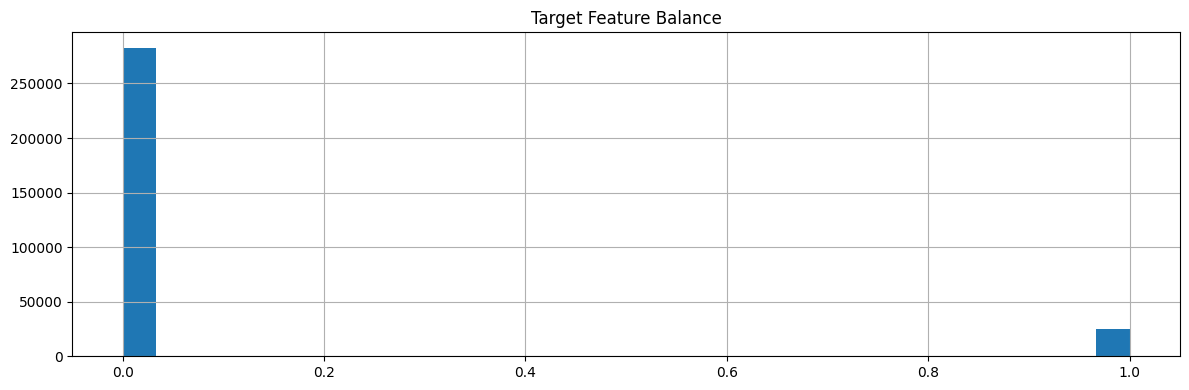

In [8]:
df['TARGET'].hist(figsize=(12,4),bins=30)
plt.title("Target Feature Balance")
plt.tight_layout()
plt.savefig(f"{IMAGES_PATH}target_feature_hist.png",dpi=150)
plt.show()

In [9]:
i = 1 
for col in df.columns:
    if df[col].dtype == "object":
        print(f"{i}. {col} -> unique values: {df[col].nunique()}")
        i += 1 

1. NAME_CONTRACT_TYPE -> unique values: 2
2. CODE_GENDER -> unique values: 3
3. FLAG_OWN_CAR -> unique values: 2
4. FLAG_OWN_REALTY -> unique values: 2
5. NAME_TYPE_SUITE -> unique values: 7
6. NAME_INCOME_TYPE -> unique values: 8
7. NAME_EDUCATION_TYPE -> unique values: 5
8. NAME_FAMILY_STATUS -> unique values: 6
9. NAME_HOUSING_TYPE -> unique values: 6
10. OCCUPATION_TYPE -> unique values: 18
11. WEEKDAY_APPR_PROCESS_START -> unique values: 7
12. ORGANIZATION_TYPE -> unique values: 58
13. FONDKAPREMONT_MODE -> unique values: 4
14. HOUSETYPE_MODE -> unique values: 3
15. WALLSMATERIAL_MODE -> unique values: 7
16. EMERGENCYSTATE_MODE -> unique values: 2


In [10]:
df['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [11]:
df[['DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE']].describe()

,DAYS_BIRTH,DAYS_ID_PUBLISH,DAYS_REGISTRATION,DAYS_LAST_PHONE_CHANGE
count,307511.000000,307511.000000,307511.000000,307510.000000
mean,-16036.995067,-2994.202373,-4986.120328,-962.858788
std,4363.988632,1509.450419,3522.886321,826.808487
min,-25229.000000,-7197.000000,-24672.000000,-4292.000000
25%,-19682.000000,-4299.000000,-7479.500000,-1570.000000
50%,-15750.000000,-3254.000000,-4504.000000,-757.000000
75%,-12413.000000,-1720.000000,-2010.000000,-274.000000
max,-7489.000000,0.000000,0.000000,0.000000


In [12]:
df['ORGANIZATION_TYPE'].unique()

array(['Business Entity Type 3', 'School', 'Government', 'Religion',
       'Other', 'XNA', 'Electricity', 'Medicine',
       'Business Entity Type 2', 'Self-employed', 'Transport: type 2',
       'Construction', 'Housing', 'Kindergarten', 'Trade: type 7',
       'Industry: type 11', 'Military', 'Services', 'Security Ministries',
       'Transport: type 4', 'Industry: type 1', 'Emergency', 'Security',
       'Trade: type 2', 'University', 'Transport: type 3', 'Police',
       'Business Entity Type 1', 'Postal', 'Industry: type 4',
       'Agriculture', 'Restaurant', 'Culture', 'Hotel',
       'Industry: type 7', 'Trade: type 3', 'Industry: type 3', 'Bank',
       'Industry: type 9', 'Insurance', 'Trade: type 6',
       'Industry: type 2', 'Transport: type 1', 'Industry: type 12',
       'Mobile', 'Trade: type 1', 'Industry: type 5', 'Industry: type 10',
       'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
       'Industry: type 13', 'Trade: type 4', 'Telecom',
       'I

In [13]:
print((df.isna().mean() * 100).sort_values(ascending=False).to_string())

COMMONAREA_MEDI                 69.872297
COMMONAREA_AVG                  69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_MODE        69.432963
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MODE           68.354953
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MEDI           68.354953
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MODE                  67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MEDI                   59.376738
LANDAREA_MODE                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_MEDI               58.515956
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
EXT_SOURCE_1                    56

In [14]:
# Antes de reemplazar, guarda la señal
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243)
# Ahora sí reemplaza
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

In [15]:
df['DAYS_EMPLOYED_ANOMALY'].head(15)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8      True
9     False
10    False
11     True
12    False
13    False
14    False
Name: DAYS_EMPLOYED_ANOMALY, dtype: bool

## EDA Summary — `application_train.csv`

### Dataset overview
- **307,511 rows, 122 columns**
- Target variable: `TARGET` (1 = default, 0 = no default)
- Class distribution: **91.9% (0) vs 8.1% (1)** — significantly imbalanced

### Missing values
- Several housing/building-related columns (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, 
  `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`, `FONDKAPREMONT_MODE`, 
  `OWN_CAR_AGE`) show missingness in the ~60-70% range.
- **Decision:** columns with >60% missing values will be dropped during the 
  feature engineering phase (after merging with auxiliary tables).

### Categorical features
- 16 object-type columns, cardinality ranging from 2 (`FLAG_OWN_CAR`) to 
  58 (`ORGANIZATION_TYPE`).
- **Decision:** 
  - Low-cardinality categoricals (2-8 categories) → one-hot encoding
  - High-cardinality categoricals (`ORGANIZATION_TYPE`, `OCCUPATION_TYPE`) → 
    frequency or target encoding (to avoid excessive dimensionality from one-hot)

### Anomalies detected
- `DAYS_EMPLOYED` contains a sentinel value of **365243** (~1000 years), 
  used to flag retired/unemployed applicants (confirmed via `NAME_INCOME_TYPE`).
- **Decision:** 
  1. Create a boolean flag column `DAYS_EMPLOYED_ANOMALY` before cleaning
  2. Replace 365243 with `NaN` in `DAYS_EMPLOYED`

### Next steps
- All cleaning and encoding decisions above will be applied **after** merging 
  `application_train` with the auxiliary tables (`bureau`, `bureau_balance`, 
  `previous_application`, `installments_payments`), to avoid redundant 
  transformations.
- Proceeding to EDA of `bureau.csv` next.

In [16]:
df['SK_ID_CURR'].duplicated().sum()

0

In [19]:
df['SK_ID_CURR'].nunique()

307511

In [18]:
numeric_cols = []
for col in df.columns:
    if df[col].dtype != "object":
        numeric_cols.append(col)